# Phase 5b — EfficientNet-B0 Comparison

Trains EfficientNet-B0 under identical conditions to ResNet18 (Phase 5),
then produces a direct architecture comparison table for the paper.

**Why EfficientNet-B0?**
- 5.3M parameters vs ResNet18's 11.7M — more efficient
- Compound scaling (depth × width × resolution) designed for accuracy/efficiency balance
- Frequently used as comparison baseline in medical imaging papers

**Protocol:** identical to Phase 5 — same data splits, same two-stage training,
same hyperparameters — so the comparison is fair and reproducible.


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

from sklearn.metrics import ConfusionMatrixDisplay

from config import DEVICE, BATCH_SIZE, FIGURES_DIR, RESULTS_DIR, MODELS_DIR, SEED
from data.dataset_loader  import load_all_datasets
from data.preprocessing   import build_dataloaders
from models.cnn_model     import build_model_arch, get_optimizer_for_arch, get_loss_fn
from models.trainer       import Trainer, evaluate_cnn

torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
print(f'Device: {DEVICE}')

Device: cuda


## 5b.1 Load datasets (same splits as Phase 5)

In [3]:
df = load_all_datasets(include=['ACRIMA', 'RIMONE', 'AIROGS'], airogs_max_samples=2000)

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

loaders = build_dataloaders(
    train_df, val_df, test_df,
    batch_size=BATCH_SIZE, num_workers=0,
)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

[ACRIMA]  Total:   705  |  Glaucoma:  396  |  Normal:  309
[RIMONE]  Total:   485  |  Glaucoma:  172  |  Normal:  313
[AIROGS]  Total:  3540  |  Glaucoma: 1770  |  Normal: 1770

────────────────────────────────────────────────────
  COMBINED  Total   : 4730
            Glaucoma: 2338
            Normal  : 2392
────────────────────────────────────────────────────
[DataLoader] train: 2749 images, 172 batches
[DataLoader] val: 931 images, 59 batches
[DataLoader] test: 1050 images, 66 batches
Train: 2749  Val: 931  Test: 1050


## 5b.2 Build EfficientNet-B0

In [4]:
eff_model = build_model_arch(
    arch='efficientnet_b0',
    pretrained=True,
    freeze_backbone=True,
)

# For reference — compare with ResNet18
resnet_total = 11_689_512
eff_total    = sum(p.numel() for p in eff_model.parameters())
print(f'\nParameter comparison:')
print(f'  ResNet18        : {resnet_total:>12,}  (Phase 5 baseline)')
print(f'  EfficientNet-B0 : {eff_total:>12,}  ({eff_total/resnet_total*100:.1f}% of ResNet18)')

EfficientNet-B0 backbone frozen — training head only.
Architecture : EfficientNet-B0
Device       : cuda
Params       : 4,010,110 total  |  2,562 trainable

Parameter comparison:
  ResNet18        :   11,689,512  (Phase 5 baseline)
  EfficientNet-B0 :    4,010,110  (34.3% of ResNet18)


## 5b.3 Stage 1 — Train head only (backbone frozen)
Identical protocol to Phase 5 — head-only warmup for 10 epochs.

In [5]:
optimizer_s1, scheduler_s1 = get_optimizer_for_arch(eff_model, stage=1)
loss_fn = get_loss_fn(train_df['label'].values)

eff_trainer = Trainer(
    eff_model, optimizer_s1, scheduler_s1, loss_fn,
    run_name='glaucoma_efficientnet_b0',
)

history_s1 = eff_trainer.fit(
    loaders['train'], loaders['val'],
    epochs=10, stage=1, patience=5,
)

Class weights — Normal: 0.998  Glaucoma: 1.002
Checkpoint → D:\Machine Learning\glaucoma detection project\outputs\models\glaucoma_efficientnet_b0_best.pth
TensorBoard → D:\Machine Learning\glaucoma detection project\outputs\logs\glaucoma_efficientnet_b0

════════════════════════════════════════════════════════════
  Stage 1 training  |  max 10 epochs  |  patience 5
════════════════════════════════════════════════════════════
  Epoch   1/10 | Train loss 0.6307  AUC 0.7232 | Val loss 0.5646  AUC 0.8302 | LR 0.000976 | 42.0s
  ✓ Best model saved  (val AUC 0.8302)
  Epoch   2/10 | Train loss 0.5892  AUC 0.7862 | Val loss 0.5431  AUC 0.8516 | LR 0.000905 | 43.0s
  ✓ Best model saved  (val AUC 0.8516)
  Epoch   3/10 | Train loss 0.5828  AUC 0.7970 | Val loss 0.5479  AUC 0.8506 | LR 0.000796 | 42.7s
  Epoch   4/10 | Train loss 0.5738  AUC 0.8096 | Val loss 0.5249  AUC 0.8559 | LR 0.000658 | 47.7s
  ✓ Best model saved  (val AUC 0.8559)
  Epoch   5/10 | Train loss 0.5836  AUC 0.7991 | Val loss

## 5b.4 Stage 2 — Full fine-tuning

In [6]:
history_s2 = eff_trainer.unfreeze_and_finetune(
    loaders['train'], loaders['val'],
    epochs=30, patience=7,
)


Loaded Stage 1 checkpoint (epoch 9, val AUC 0.8657)
EfficientNet-B0 backbone unfrozen — full fine-tuning.
Stage 2 starts. Current best val AUC: 0.8657

════════════════════════════════════════════════════════════
  Stage 2 training  |  max 30 epochs  |  patience 7
════════════════════════════════════════════════════════════
  Epoch   1/30 | Train loss 0.5541  AUC 0.8381 | Val loss 0.4844  AUC 0.9115 | LR 0.000099 | 44.8s
  ✓ Best model saved  (val AUC 0.9115)
  Epoch   2/30 | Train loss 0.4826  AUC 0.8973 | Val loss 0.4448  AUC 0.9230 | LR 0.000098 | 47.3s
  ✓ Best model saved  (val AUC 0.9230)
  Epoch   3/30 | Train loss 0.4500  AUC 0.9177 | Val loss 0.4195  AUC 0.9371 | LR 0.000095 | 44.1s
  ✓ Best model saved  (val AUC 0.9371)
  Epoch   4/30 | Train loss 0.4128  AUC 0.9398 | Val loss 0.4054  AUC 0.9453 | LR 0.000091 | 44.8s
  ✓ Best model saved  (val AUC 0.9453)
  Epoch   5/30 | Train loss 0.4070  AUC 0.9418 | Val loss 0.3972  AUC 0.9498 | LR 0.000086 | 44.5s
  ✓ Best model saved  

## 5b.5 Training curves

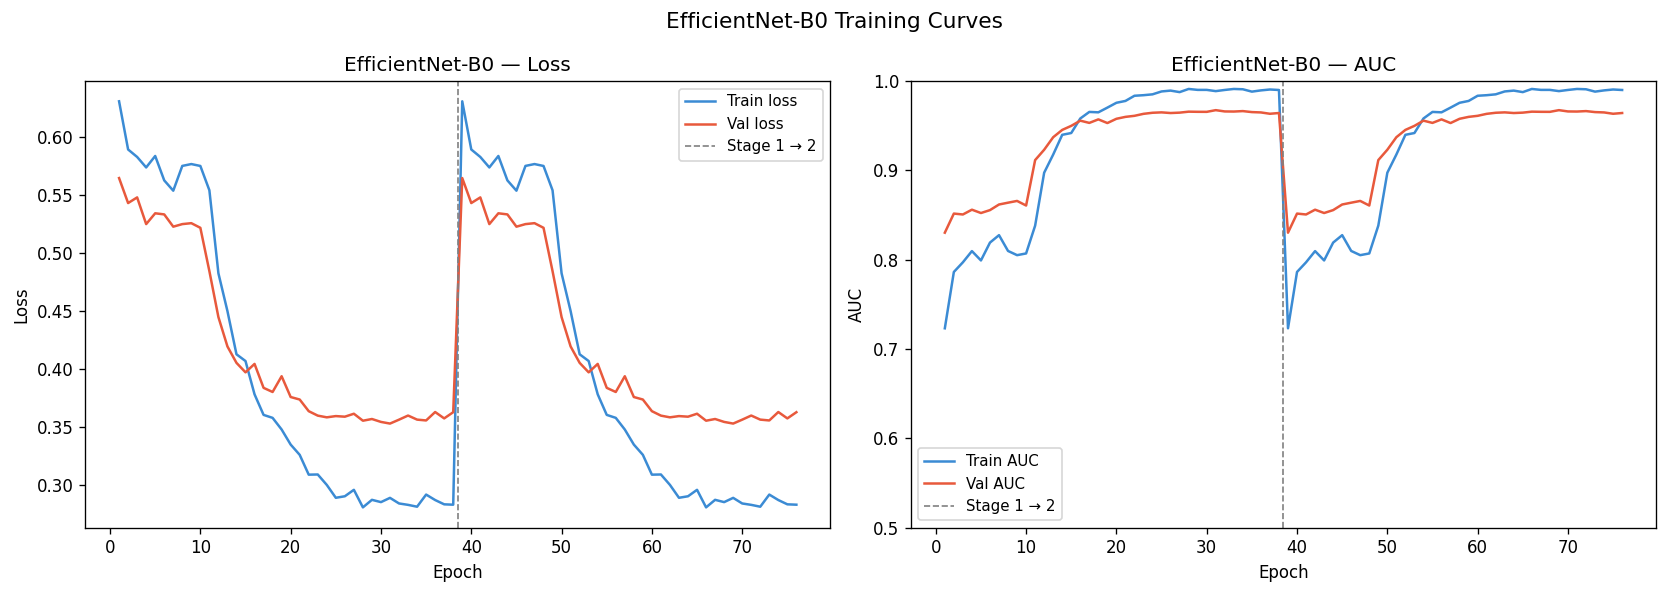

In [7]:
s1_len = len(history_s1['train_loss'])
full_history = {k: history_s1[k] + history_s2.get(k, []) for k in history_s1}
epochs_range = range(1, len(full_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, full_history['train_loss'], '#3B8BD4', label='Train loss')
ax1.plot(epochs_range, full_history['val_loss'],   '#E8593C', label='Val loss')
ax1.axvline(s1_len + 0.5, color='gray', linestyle='--', linewidth=1, label='Stage 1 → 2')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('EfficientNet-B0 — Loss'); ax1.legend(fontsize=9)

ax2.plot(epochs_range, full_history['train_auc'], '#3B8BD4', label='Train AUC')
ax2.plot(epochs_range, full_history['val_auc'],   '#E8593C', label='Val AUC')
ax2.axvline(s1_len + 0.5, color='gray', linestyle='--', linewidth=1, label='Stage 1 → 2')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('EfficientNet-B0 — AUC'); ax2.legend(fontsize=9)
ax2.set_ylim([0.5, 1.0])

plt.suptitle('EfficientNet-B0 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'efficientnet_training_curves.png', bbox_inches='tight')
plt.show()

## 5b.6 Evaluate on test set

In [8]:
eff_model = eff_trainer.load_best()
eff_metrics = evaluate_cnn(eff_model, loaders['test'])

print('\n── EfficientNet-B0 Test Results ──')
for k, v in eff_metrics.items():
    if k not in ['y_true','y_pred','y_prob','fpr','tpr']:
        print(f'  {k:<14}: {v:.4f}')

Loaded best model: epoch 21, val AUC 0.9674

── EfficientNet-B0 Test Results ──
  auc           : 0.9292
  sensitivity   : 0.9040
  specificity   : 0.8018
  f1            : 0.8520
  accuracy      : 0.8505
  tp            : 452.0000
  fp            : 109.0000
  tn            : 441.0000
  fn            : 48.0000


## 5b.7 Architecture comparison table

In [9]:
# Load ResNet18 results from Phase 5
resnet_saved = joblib.load(RESULTS_DIR / 'cnn_test_results.pkl')

arch_comparison = pd.DataFrame([
    {
        'Architecture':   'ResNet18',
        'Parameters (M)': 11.7,
        'AUC':            round(resnet_saved['auc'],         4),
        'Sensitivity':    round(resnet_saved['sensitivity'], 4),
        'Specificity':    round(resnet_saved['specificity'], 4),
        'F1':             round(resnet_saved['f1'],          4),
        'Accuracy':       round(resnet_saved['accuracy'],    4),
    },
    {
        'Architecture':   'EfficientNet-B0',
        'Parameters (M)': round(eff_total / 1e6, 1),
        'AUC':            round(eff_metrics['auc'],         4),
        'Sensitivity':    round(eff_metrics['sensitivity'], 4),
        'Specificity':    round(eff_metrics['specificity'], 4),
        'F1':             round(eff_metrics['f1'],          4),
        'Accuracy':       round(eff_metrics['accuracy'],    4),
    },
])

print('\n── Architecture Comparison ──')
display(arch_comparison.style
    .highlight_max(subset=['AUC','Sensitivity','Specificity','F1','Accuracy'],
                   color='#d4edda')
    .format({'Parameters (M)': '{:.1f}',
             'AUC': '{:.4f}', 'Sensitivity': '{:.4f}',
             'Specificity': '{:.4f}', 'F1': '{:.4f}', 'Accuracy': '{:.4f}'})
)

arch_comparison.to_csv(RESULTS_DIR / 'architecture_comparison.csv', index=False)

# LaTeX table for paper
latex = arch_comparison.to_latex(
    index=False,
    caption='Architecture comparison: ResNet18 vs EfficientNet-B0 on the held-out test set.',
    label='tab:arch_comparison',
    column_format='lcccccc',
)
(RESULTS_DIR / 'architecture_comparison.tex').write_text(latex)
print(f'\nSaved CSV + LaTeX → {RESULTS_DIR}')


── Architecture Comparison ──


,Architecture,Parameters (M),AUC,Sensitivity,Specificity,F1,Accuracy
0,ResNet18,11.7,0.9445,0.9320,0.8164,0.8735,0.8714
1,EfficientNet-B0,4.0,0.9292,0.9040,0.8018,0.8520,0.8505



Saved CSV + LaTeX → D:\Machine Learning\glaucoma detection project\outputs\results


## 5b.8 ROC curve overlay — ResNet18 vs EfficientNet-B0

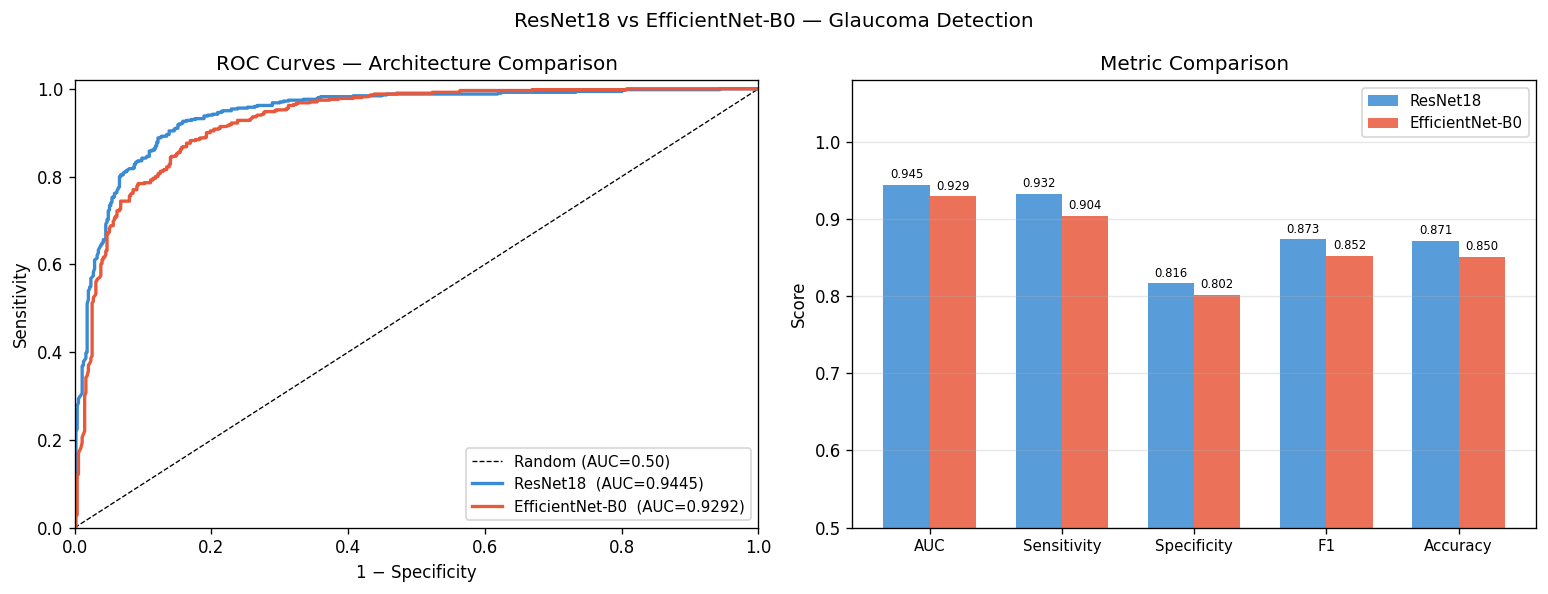

Saved → D:\Machine Learning\glaucoma detection project\outputs\figures\architecture_comparison.png


In [10]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ROC overlay ────────────────────────────────────────────────
ax = axes[0]
ax.plot([0,1],[0,1],'k--',linewidth=0.8,label='Random (AUC=0.50)')

resnet_fpr = np.array(resnet_saved['fpr'])
resnet_tpr = np.array(resnet_saved['tpr'])
ax.plot(resnet_fpr, resnet_tpr,
        color='#3B8BD4', linewidth=2,
        label=f"ResNet18  (AUC={resnet_saved['auc']:.4f})")
ax.plot(eff_metrics['fpr'], eff_metrics['tpr'],
        color='#E8593C', linewidth=2,
        label=f"EfficientNet-B0  (AUC={eff_metrics['auc']:.4f})")

ax.set_xlabel('1 − Specificity'); ax.set_ylabel('Sensitivity')
ax.set_title('ROC Curves — Architecture Comparison')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# ── Right: Metric bar chart ───────────────────────────────────────────
ax2    = axes[1]
metrics_to_plot = ['AUC', 'Sensitivity', 'Specificity', 'F1', 'Accuracy']
resnet_vals = [resnet_saved['auc'], resnet_saved['sensitivity'],
               resnet_saved['specificity'], resnet_saved['f1'], resnet_saved['accuracy']]
eff_vals    = [eff_metrics['auc'], eff_metrics['sensitivity'],
               eff_metrics['specificity'], eff_metrics['f1'], eff_metrics['accuracy']]

x  = np.arange(len(metrics_to_plot))
w  = 0.35
b1 = ax2.bar(x - w/2, resnet_vals, w, color='#3B8BD4', alpha=0.85, label='ResNet18')
b2 = ax2.bar(x + w/2, eff_vals,    w, color='#E8593C', alpha=0.85, label='EfficientNet-B0')

for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax2.set_xticks(x); ax2.set_xticklabels(metrics_to_plot, fontsize=9)
ax2.set_ylim([0.5, 1.08]); ax2.set_ylabel('Score')
ax2.set_title('Metric Comparison')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('ResNet18 vs EfficientNet-B0 — Glaucoma Detection', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'architecture_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved → {FIGURES_DIR / "architecture_comparison.png"}')

## 5b.9 Confusion matrix — EfficientNet-B0

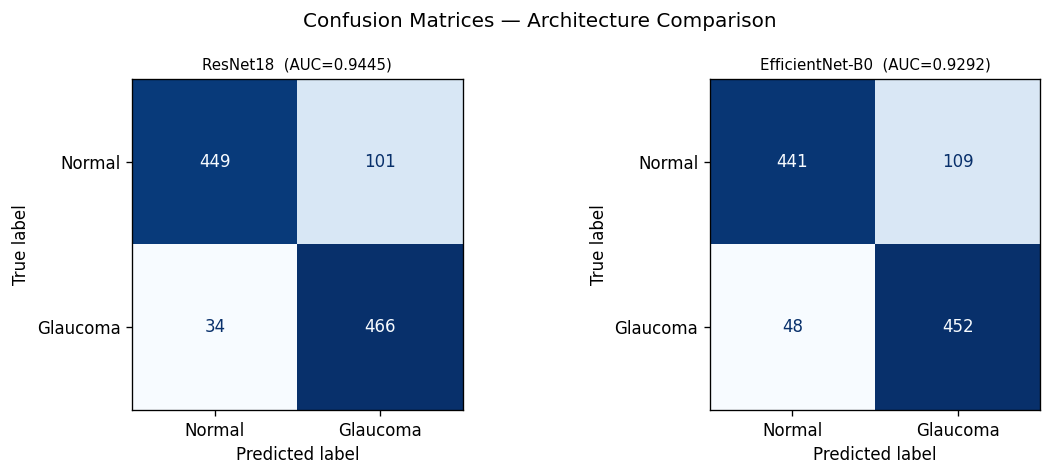

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0],
     np.array(resnet_saved['y_true']), np.array(resnet_saved['y_pred']),
     f"ResNet18  (AUC={resnet_saved['auc']:.4f})"),
    (axes[1],
     eff_metrics['y_true'], eff_metrics['y_pred'],
     f"EfficientNet-B0  (AUC={eff_metrics['auc']:.4f})"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Normal', 'Glaucoma'],
        cmap='Blues', ax=ax, colorbar=False,
    )
    ax.set_title(title, fontsize=9)

plt.suptitle('Confusion Matrices — Architecture Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'architecture_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 5b.10 Save EfficientNet results

In [12]:
eff_save = {k: (v.tolist() if hasattr(v, 'tolist') else v)
            for k, v in eff_metrics.items()}
joblib.dump(eff_save, RESULTS_DIR / 'efficientnet_test_results.pkl')
print(f'Saved → {RESULTS_DIR / "efficientnet_test_results.pkl"}')

print('\n── Final Comparison Summary ──')
winner = 'ResNet18' if resnet_saved['auc'] > eff_metrics['auc'] else 'EfficientNet-B0'
delta  = abs(resnet_saved['auc'] - eff_metrics['auc'])
print(f'Best AUC         : {winner}  (Δ={delta:.4f})')
print(f'ResNet18 AUC     : {resnet_saved["auc"]:.4f}  |  '
      f'Sensitivity: {resnet_saved["sensitivity"]:.4f}  |  '
      f'Params: 11.7M')
print(f'EfficientNet AUC : {eff_metrics["auc"]:.4f}  |  '
      f'Sensitivity: {eff_metrics["sensitivity"]:.4f}  |  '
      f'Params: {eff_total/1e6:.1f}M')
print(f'\nPaper sentence:')
print(f'"Both ResNet18 (AUC={resnet_saved["auc"]:.3f}) and EfficientNet-B0 '
      f'(AUC={eff_metrics["auc"]:.3f}) significantly outperformed classical ML '
      f'baselines (best AUC=0.789, SVM-RBF). {winner} achieved higher AUC '
      f'with a margin of {delta:.3f}."')

Saved → D:\Machine Learning\glaucoma detection project\outputs\results\efficientnet_test_results.pkl

── Final Comparison Summary ──
Best AUC         : ResNet18  (Δ=0.0153)
ResNet18 AUC     : 0.9445  |  Sensitivity: 0.9320  |  Params: 11.7M
EfficientNet AUC : 0.9292  |  Sensitivity: 0.9040  |  Params: 4.0M

Paper sentence:
"Both ResNet18 (AUC=0.945) and EfficientNet-B0 (AUC=0.929) significantly outperformed classical ML baselines (best AUC=0.789, SVM-RBF). ResNet18 achieved higher AUC with a margin of 0.015."


---
## ✅ Phase 5b complete

Files added:
- `outputs/models/glaucoma_efficientnet_b0_best.pth`
- `outputs/results/efficientnet_test_results.pkl`
- `outputs/results/architecture_comparison.csv` + `.tex`
- `outputs/figures/architecture_comparison.png`  (300 DPI)
- `outputs/figures/efficientnet_training_curves.png`
- `outputs/figures/architecture_confusion_matrices.png`

**Interpreting the result for the paper:**
- If ResNet18 wins → justify: simpler architecture, fewer params, better for small datasets, strong Grad-CAM interpretability
- If EfficientNet-B0 wins → justify: compound scaling, more expressive features, better generalisation
- Either outcome strengthens the paper — you now have an architecture ablation section

**Next → CNN + SVM + CDR Ensemble** (highest paper impact addition)